# Notebook dedicated to analyze neutron simulations for RATv8. For now, the observables to be analyzed will be:

- Mean neutron distance within scintillator
- Energy spectrum of released gammas on neutron capture

In [30]:
import glob

import numpy as np
import pylandau
from lmfit import Model
from scipy.optimize import curve_fit
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sn
from matplotlib import font_manager
from matplotlib.ticker import MultipleLocator, ScalarFormatter

In [3]:
def set_ticks(ax, min_mark, maj_mark):
    # ---- X axis ----
    ax.xaxis.set_minor_locator(MultipleLocator(min_mark))
    ax.xaxis.set_major_formatter(ScalarFormatter(maj_mark))

    # ---- X axis Formatter  ----
    formatter = ScalarFormatter()
    formatter.set_useOffset(False)  # avoid inconvenient representation of axis values
    ax.xaxis.set_major_formatter(formatter)

    # ---- Y axis ----
    #ax.yaxis.set_minor_locator(MultipleLocator(5))
    #ax.yaxis.set_major_formatter(ScalarFormatter())

    # ---- Show ticks on all sides ----
    ax.tick_params(which='minor', top=True, bottom=True, left=True, right=True)
    ax.tick_params(which='major', top=True, bottom=True, left=True, right=True)

# Load Data

In [43]:
#fdir = 'C:/Users/joanc/jupyter_notebooks/rat_tests/rat_v8/neutrons/results/'
fdir = '/home/joankl/data/rat_test/rat_v8/neutrons/np_files/'
fdir_list = glob.glob(fdir + 'neutron_3MeV_*.npz')

neutron_distance = np.array([])    # Neutron Capture Distance (mm)
time_capture = np.array([])        # Neutron Capture Time (ns)
gammas_energy = np.array([])       # Energy of Released Gammas after neutron Capture (MeV)
step_count = np.array([])          # Nº of steps = Nº of collisions before neutron capture
capture_nuclei_code = np.array([]) # code of heavy nuclei that captures the neutron

for fdir_i in fdir_list:
    neutron_data = np.load(fdir_i)
    
    neutron_distance = np.append(neutron_distance, neutron_data['distances']) 
    time_capture = np.append(time_capture, neutron_data['capture_times'] ) 
    gammas_energy = np.append(gammas_energy, neutron_data['gamma_energies']) 
    step_count = np.append(step_count, neutron_data['step_counts'])       
    capture_nuclei_code = np.append(capture_nuclei_code, neutron_data['capture_nuclei']) 


time_capture = time_capture*1e-3  #Transform units from nanoseconds to microseconds

# Plots

## Traveling neutron distance

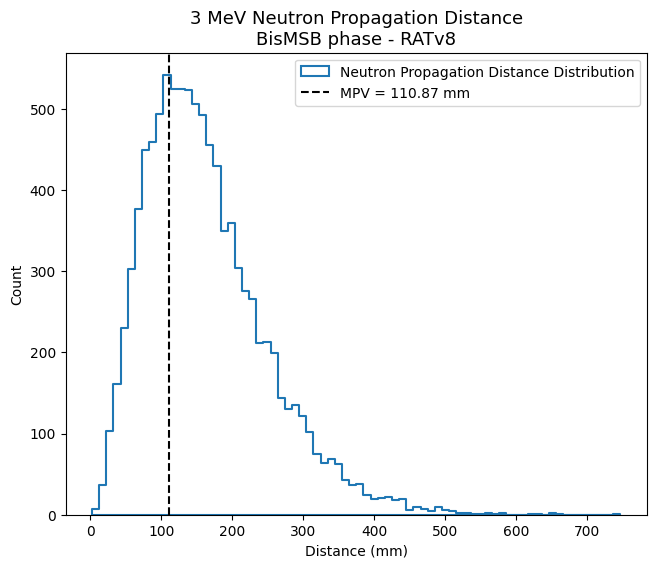

In [91]:
bins = 'auto'

# ---- Fit Procedure: Consider a Moyal distribution (aprox. to Landau distribution) to obtain the Most-Probable-Value (MPV) ----
fitted_loc, fitted_scale = stats.moyal.fit(neutron_distance)
mpv = fitted_loc

# ---- Plot Constructions ----
fig, axes = plt.subplots(figsize=(7.5,6))
sn.histplot(neutron_distance, bins = bins, element = 'step', alpha=0, linewidth = 1.5, label = 'Neutron Propagation Distance Distribution')
plt.axvline(mpv, label = rf'MPV = {mpv:.2f} mm', color = 'black', ls = '--')

plt.xlabel('Distance (mm)')

plt.legend()

plt.title('3 MeV Neutron Propagation Distance'+ '\n' +'BisMSB phase - RATv8', fontsize = 13)

plt.show()

## Neutron Capture Time

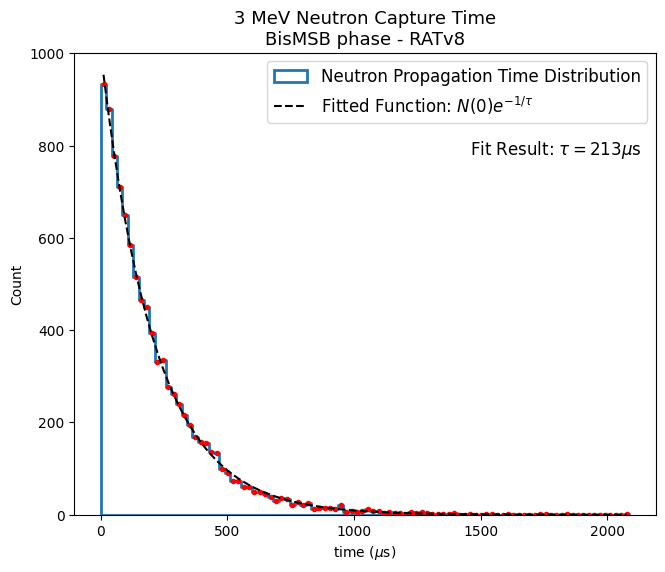

In [98]:
bins = 'auto'

# ---- Fit Procedure: Consider an exponential decay to extract the 'half-life' of the neutron capture ----
def fit_exp(x, n0, lambda_):
    return n0 * np.exp(lambda_ * x)

counts, bin_edges = np.histogram(time_capture, bins = bins)
bins_center = (bin_edges[:-1] + bin_edges[1:])/2
bins_center = np.round(bins_center, decimals = 2)

fit_model_dt = Model(fit_exp)
fit_results = fit_model_dt.fit(counts, x = bins_center, n0 = 1, lambda_ = 1/150)

lambda_ = fit_results.best_values['lambda_']
tau = -1/lambda_

# ---- Plot Constructions ----
fig,ax = plt.subplots(figsize = (7.5,6))
sn.histplot(time_capture, bins = bins, element = 'step', alpha=0, linewidth = 2, label = 'Neutron Propagation Time Distribution')
plt.scatter(x = bins_center, y = counts, color = 'r', marker='.')
plt.plot(bins_center, fit_results.best_fit, label = rf'Fitted Function: $N(0) e^{{-1/\tau}}$', ls = '--', color = 'black' )

plt.text(0.68, 0.78, rf'Fit Result: $\tau = {tau:.0f} \mu$s', transform=ax.transAxes, fontsize=12)


plt.xlabel(r'time ($\mu$s)')
plt.legend(loc = 'upper right', fontsize=12)

plt.title('3 MeV Neutron Capture Time'+ '\n' +'BisMSB phase - RATv8', fontsize = 13)
#Exp. fit Half-Life $\tau$ = {tau:.0f} $\mu$s

plt.show()

## Nº of Collision Before Neutron Capture

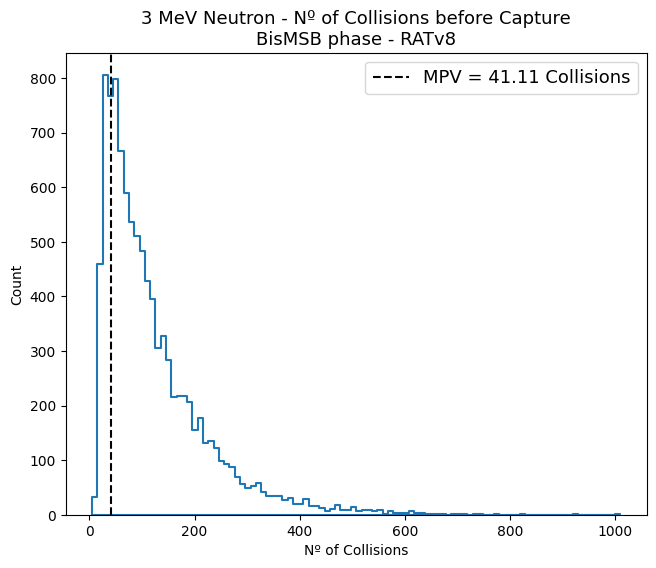

In [100]:
bins = 'auto'

# ---- Fit Procedure: Use the Landau definition provided by the package pylandau which follows the approximation in http://dx.doi.org/10.1016/0010-4655(84)90085-7  ----
counts, bin_edges = np.histogram(step_count, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
opt_val, _ = curve_fit(pylandau.landau, bin_centers, counts, p0=[50, 5])

mpv = opt_val[0]

# ---- Plots Contruction ----
fig, axes = plt.subplots(figsize=(7.5,6))

sn.histplot(step_count, bins = bins, element = 'step', alpha=0, linewidth = 1.5)
plt.axvline(mpv, label = rf'MPV = {mpv:.2f} Collisions', color = 'black', ls = '--')

plt.xlabel('Nº of Collisions')
plt.legend(fontsize = 13)

plt.title('3 MeV Neutron - Nº of Collisions before Capture'+ '\n' +'BisMSB phase - RATv8', fontsize = 13)

plt.show()

## $\gamma$ from n-capture spectrum

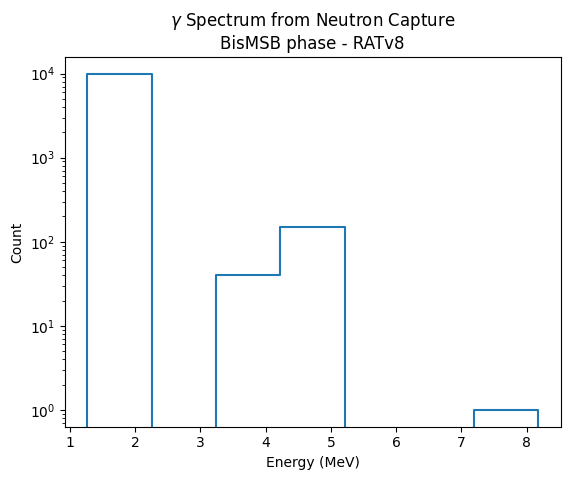

In [101]:
bins = 7

sn.histplot(gammas_energy, bins = bins, element = 'step', alpha=0, linewidth = 1.5)

plt.title(r'$\gamma$ Spectrum from Neutron Capture'+ '\n' +'BisMSB phase - RATv8')

plt.xlabel('Energy (MeV)')

plt.yscale('log')

plt.show()

# Neutron Capure on Nuclei - Gamma Release

In [102]:
unique_code_n_capture = np.unique(capture_nuclei_code).astype(np.int64)
unique_code_n_capture

array([1000010020, 1000060130, 1000060140])

PDG Code: 100ZZZAAAI (ZZZ - > Atomic number, AAA -> Mass number)
Capture on:

1) 1000010020: H-2 (Deuterium)
2) 1000060130: C-16
3) 1000070150: N-15

# Notes

- Improve statistics
- measure MPV of neutron capture distance
- exponential fit to neutron capture time
- Measure for different neutron energies: Traveled distance, Nº of collisions, ...